In [62]:
#Project #5: Examine TCR violations across 5 States (Water Quality #2)

#Import packages 
import pandas as pd
import requests   # package not used in class → satisfies requirement
import matplotlib.pyplot as plt
import seaborn as sns

#Seaborn 1 of 3 packages used 
sns.set_style('whitegrid')
sns.set_palette('deep')


In [63]:
##1 Data loading and verification 
#All 5 states data were downloaded as one merged set. 
#Data was previously cleaned in Excel. Column names contain spaces instead of underscores.

# 1.1 Load states data into pandas
States_data = pd.read_csv("CIVE202_ViolationReportData.csv", low_memory=False)
States_data = pd.DataFrame(States_data)

print(States_data.isna().sum())
States_data.head()


Submission_Year_Quarter             0
EPA_Region                          0
State                               0
Primacy_Type                        0
PWS_ID                              0
PWS_Name                            0
PWS_Type                            0
GW_SW                               0
Primary_Source                      0
PWS_Activity_Type                   0
PWS_Deactivation_Date           39100
Population_Served_Count             0
Pop_Cat_5                           0
Violation_ID                        0
Is_Health_Based                     0
Rule_Name                           0
Violation_Type                      0
Compliance_Period_Begin_Date        0
Compliance_Period_End_Date      13238
Compliance_Status                   0
RTC_Date                         3746
dtype: int64


,Submission_Year_Quarter,EPA_Region,State,Primacy_Type,PWS_ID,PWS_Name,PWS_Type,GW_SW,Primary_Source,PWS_Activity_Type,...,Population_Served_Count,Pop_Cat_5,Violation_ID,Is_Health_Based,Rule_Name,Violation_Type,Compliance_Period_Begin_Date,Compliance_Period_End_Date,Compliance_Status,RTC_Date
0,2026Q1,3,PA,State,PA4410019,PINECREST_VILLAGE_MHP,Community_water_system,Surface_water,Groundwater_under_influence_of_surface_water,Active,...,195,<=500,2322638,Y,Revised_Total_Coliform_Rule,"Maximum_Contaminant_Level_Violation,_E._coli_(...",1-Apr-23,30-Apr-23,Returned_to_Compliance,2-Nov-23
1,2026Q1,3,PA,State,PA3480032,WALNUTPORT_AUTHORITY,Community_water_system,Surface_water,Groundwater_under_influence_of_surface_water,Active,...,"3,000","501-3,300",2428950,Y,Revised_Total_Coliform_Rule,"Maximum_Contaminant_Level_Violation,_E._coli_(...",1-Aug-24,31-Aug-24,Returned_to_Compliance,8-Oct-24
2,2026Q1,1,MA,State,MA2287000,STURBRIDGE_WATER_DEPARTMENT,Community_water_system,Surface_water,Groundwater_under_influence_of_surface_water,Active,...,"4,567","3,301-10,000",2,Y,Revised_Total_Coliform_Rule,"Maximum_Contaminant_Level_Violation,_E._coli_(...",1-Jul-19,31-Jul-19,Returned_to_Compliance,21-Oct-19
3,2026Q1,9,CA,State,CA2400167,BALLICO_CSD,Community_water_system,Groundwater,Ground_water,Active,...,238,<=500,29,Y,Revised_Total_Coliform_Rule,"Maximum_Contaminant_Level_Violation,_E._coli_(...",1-Aug-24,31-Aug-24,Known,NaN
4,2026Q1,1,MA,State,MA2034027,BOLTON_COUNTRY_MANOR,Community_water_system,Groundwater,Ground_water,Active,...,60,<=500,10,Y,Revised_Total_Coliform_Rule,"Maximum_Contaminant_Level_Violation,_E._coli_(...",1-Jul-18,31-Jul-18,Known,NaN


In [75]:
##2 Clean and organize data

# 2.1 Standardize column names (spaces → underscores) was done in Xcel


In [76]:
# 2.2 Clean population_served_count
States_data["state"] = (
    States_data["state"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

States_data["population_served_count_clean"] = pd.to_numeric(
    States_data["population_served_count_clean"],
    errors="coerce"
)


In [77]:
# 2.3 Extract year from submission_year_quarter
States_data["year"] = States_data["submission_year_quarter"].astype(str).str[:4]

In [78]:
##3 Define and use a function

# 3.1 Function to classify system size
def classify_system_size(pop):
    """
    Classify system size based on population served.
    Threshold choice introduces bias:
    - Small: <= 10,000
    - Large: > 10,000
    """
    if pd.isna(pop):
        return "Unknown"
    return "Small" if pop <= 10000 else "Large"

States_data["system_size"] = States_data["population_served_count_clean"].apply(classify_system_size)



In [79]:
##4 Summary tables

# 4.1 
violations_by_state = States_data.groupby('state').size().reset_index(name='total_violations')
print(violations_by_state)

violations_by_popcat = States_data.groupby('pop_cat_5').size().reset_index(name='total_violations')
print(violations_by_popcat)

violations_by_year = States_data.groupby('year').size().reset_index(name='total_violations')
print(violations_by_year)

  state  total_violations
0    CA              3980
1    IA              2154
2    IL              3415
3    MA              1235
4    PA             28316
        pop_cat_5  total_violations
0  10,001-100,000               332
1    3,301-10,000               496
2       501-3,300              2829
3           <=500             35411
4        >100,000                32
   year  total_violations
0  2026             39100


In [80]:
# 4.2 
violations_by_state.columns = ['State', 'Total Violations']
violations_by_popcat.columns = ['System Size', 'Total Violations']
violations_by_year.columns = ['Year', 'Total Violations']

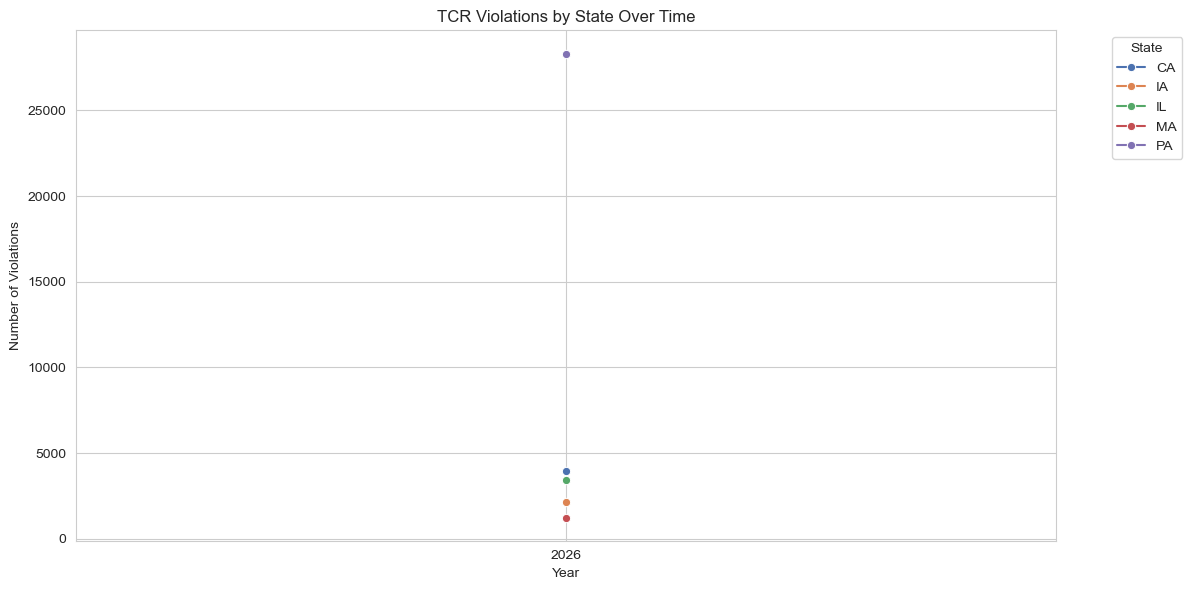

In [81]:
##5 Graph 1 – Violations by state over time

plt.figure(figsize=(12,6))
sns.lineplot(
    data=violations_by_state_year,
    x="year",
    y="total_violations",
    hue="state",
    marker="o"
)
plt.title("TCR Violations by State Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Violations")
plt.legend(title="State", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


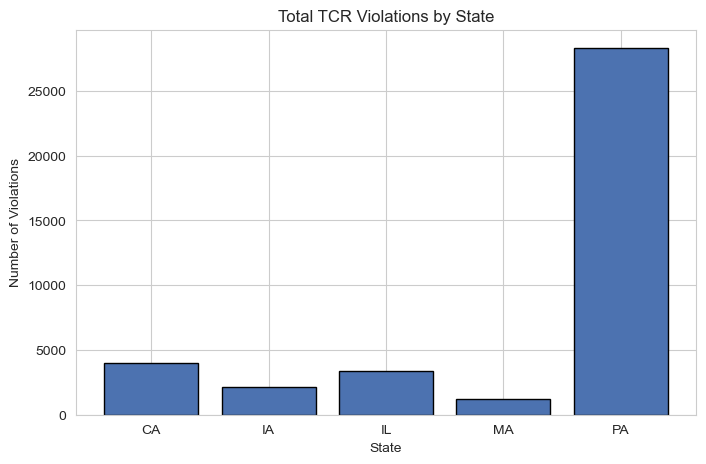

In [82]:
#Graph 2 – Violation count by State
plt.figure(figsize=(8,5))

plt.bar(violations_by_state['State'], violations_by_state['Total Violations'], edgecolor='black')

plt.xlabel("State")
plt.ylabel("Number of Violations")
plt.title("Total TCR Violations by State")

plt.show()

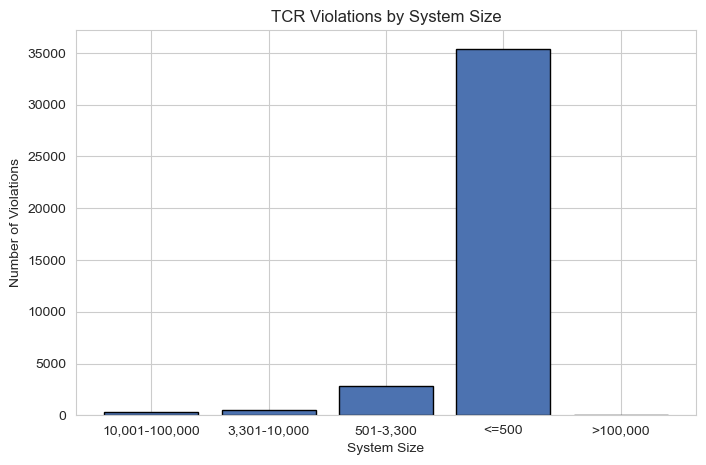

In [83]:
#Graph 3 - Violation size quanitity
plt.figure(figsize=(8,5))

plt.bar(violations_by_popcat['System Size'], violations_by_popcat['Total Violations'], edgecolor='black')

plt.xlabel("System Size")
plt.ylabel("Number of Violations")
plt.title("TCR Violations by System Size")

plt.xticks(rotation=0)

plt.show()